# **1.)Importing Dependencies**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer   
from sklearn.metrics.pairwise import cosine_similarity          
from sentence_transformers import SentenceTransformer           

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# **2.)Exploratory Data Analysis**

In [17]:
#Loading Datasets into respective variables
print('-'*41)
print('1.)Loading Dataset')
print('-'*41)
print('2.)Analyzing Shape of the Dataset')
print('-'*41)

#Analayzing shapes of the datasets
train_df=pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print(f"Shape of the training dataset : {train_df.shape}")
print(f"Shape of the test dataset : {test_df.shape}")
print('-'*41)


-----------------------------------------
1.)Loading Dataset
-----------------------------------------
2.)Analyzing Shape of the Dataset
-----------------------------------------
Shape of the training dataset : (2000, 8)
Shape of the test dataset : (500, 7)
-----------------------------------------


In [4]:
#Making a copy of training dataset to  avoid errors
X=train_df.copy()

In [6]:
X.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [28]:
#Sanity Checks

print('-'*43)
print(X.isnull().sum())
print('-'*43)

print(X.dtypes)
print('-'*43)

print("Duplicate prompts:", X.duplicated(subset=['prompt']).sum())
print('-'*43)

print("Unique answer values:", X['answer'].unique())
print('-'*43)


-------------------------------------------
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
-------------------------------------------
id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object
-------------------------------------------
Duplicate prompts: 242
-------------------------------------------
Unique answer values: ['B' 'A' 'C' 'E' 'D']
-------------------------------------------


answer
A    0.1845
B    0.2450
C    0.2295
D    0.1790
E    0.1620
Name: proportion, dtype: float64


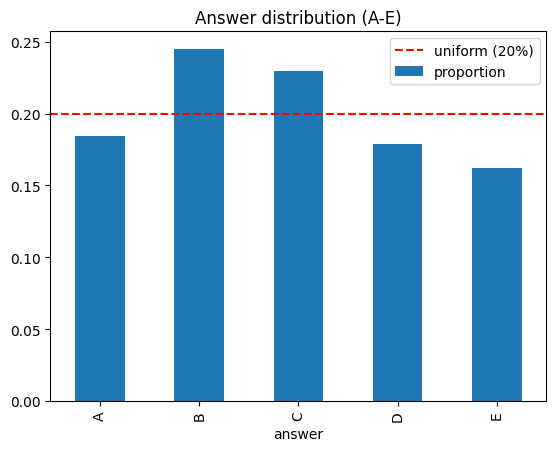

In [29]:
#answer distribution
counts = X['answer'].value_counts(normalize=True).sort_index()
print(counts)

counts.plot(kind='bar', title='Answer distribution (A-E)')
plt.axhline(0.2, color='red', linestyle='--', label='uniform (20%)')
plt.legend()
plt.show()

In [8]:
sample=pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
sample.to_csv("submission.csv",index=False)

In [9]:
#wnb key 
#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
#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